<a href="https://colab.research.google.com/github/yamatai-wizard/GCI_Competition2/blob/test/NFL_Draft_Prediction_ipynb%E3%80%80%E5%AE%9F%E8%A1%8C%E7%89%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 第2回データ分析コンペティション：NFL Draft Prediction

## 目次
1. セットアップ
2. データ読み込み
3. データの分析・EDA
4. 前処理
5. ベースラインモデル
6. 仮説と特徴量エンジニアリング
7. 提出ファイル作成
8. 今後の展望

## 1. セットアップ

In [91]:
from google.colab import drive,files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, auc

from xgboost import XGBClassifier

!pip install optuna
import optuna
from optuna.samplers import TPESampler

In [93]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 2. データ読み込み

In [94]:
PATH = '/content/drive/MyDrive/GCI/NFL Draft Prediction/'

train = pd.read_csv(PATH + 'train.csv')
test = pd.read_csv(PATH + 'test.csv')

## 4. 前処理

In [95]:
# 使わない列の削除
train = train.drop(columns=["Id"])
test = test.drop(columns=["Id"])

In [96]:
# prompt: 欠損値を全て-9999で埋める

train = train.fillna(-9999)
test = test.fillna(-9999)

In [97]:
train.isnull().sum()

,0
Year,0
Age,0
School,0
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0
Agility_3cone,0


In [98]:
test.isnull().sum()

,0
Year,0
Age,0
School,0
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0
Agility_3cone,0


In [99]:
# カテゴリデータをラベルエンコーディング
label_encoders = {}
for c in ["Player_Type", "Position_Type", "Position"]:
    label_encoders[c] = LabelEncoder()
    train[c] = label_encoders[c].fit_transform(train[c].astype(str))
    test[c] = label_encoders[c].transform(test[c].astype(str))

In [100]:
# # カテゴリデータのワンホットエンコーディング
# train = pd.get_dummies(train, columns=["Player_Type", "Position_Type", "Position"], dummy_na=False, dtype=int)
# test = pd.get_dummies(test, columns=["Player_Type", "Position_Type", "Position"], dummy_na=False, dtype=int)

# # trainとtestでカラムを揃える
# train_cols = set(train.columns)
# test_cols = set(test.columns)

# missing_in_test = list(train_cols - test_cols)
# for c in missing_in_test:
#     if c != 'Drafted': # 'Drafted' はtestには存在しない
#         test[c] = 0.0

# missing_in_train = list(test_cols - train_cols)
# for c in missing_in_train:
#     train[c] = 0.0

# # カラムの順序をtrainに合わせる
# test = test[train.columns.drop('Drafted')]

In [101]:
train.head()

,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,1,5,10,1.0
1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,-9999.00,-9999.00,1,0,19,1.0
2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,1,0,19,1.0
3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,0,2,4,1.0
4,2016,21.0,California,1.8796,92.079251,4.64,78.74,-9999.0,281.94,7.13,4.20,1,0,19,1.0


## 6. 仮説と特徴量エンジニアリング

In [102]:
# prompt: 交差項の作成して'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
#     'Broad_Jump', 'Agility_3cone', 'Shuttle'

import pandas as pd
# 特徴量エンジニアリング：交差項の作成
interaction_features = ['Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                        'Broad_Jump', 'Agility_3cone', 'Shuttle']

# PolynomialFeaturesを使用して交差項を生成
# degree=2で2次の項と交差項を生成、include_bias=Falseでバイアス項を含めない
poly = PolynomialFeatures(degree=2, include_bias=False)

# trainとtestの指定された特徴量に対して交差項を生成
train_interaction = poly.fit_transform(train[interaction_features])
test_interaction = poly.transform(test[interaction_features])

# 生成された交差項をDataFrameに変換
# get_feature_names_outで生成された特徴量の名前を取得
train_interaction_df = pd.DataFrame(train_interaction, columns=poly.get_feature_names_out(interaction_features))
test_interaction_df = pd.DataFrame(test_interaction, columns=poly.get_feature_names_out(interaction_features))

# 元のDataFrameから交差項のもとになった特徴量を削除
train = train.drop(columns=interaction_features)
test = test.drop(columns=interaction_features)

# 生成された交差項を元のDataFrameに追加
train = pd.concat([train.reset_index(drop=True), train_interaction_df.reset_index(drop=True)], axis=1)
test = pd.concat([test.reset_index(drop=True), test_interaction_df.reset_index(drop=True)], axis=1)

print("Train shape after adding interaction features:", train.shape)
print("Test shape after adding interaction features:", test.shape)
train.head()


Train shape after adding interaction features: (2781, 51)
Test shape after adding interaction features: (696, 50)


,Year,Age,School,Player_Type,Position_Type,Position,Drafted,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Height^2,Height Weight,Height Sprint_40yd,Height Vertical_Jump,Height Bench_Press_Reps,Height Broad_Jump,Height Agility_3cone,Height Shuttle,Weight^2,Weight Sprint_40yd,Weight Vertical_Jump,Weight Bench_Press_Reps,Weight Broad_Jump,Weight Agility_3cone,Weight Shuttle,Sprint_40yd^2,Sprint_40yd Vertical_Jump,Sprint_40yd Bench_Press_Reps,Sprint_40yd Broad_Jump,Sprint_40yd Agility_3cone,Sprint_40yd Shuttle,Vertical_Jump^2,Vertical_Jump Bench_Press_Reps,Vertical_Jump Broad_Jump,Vertical_Jump Agility_3cone,Vertical_Jump Shuttle,Bench_Press_Reps^2,Bench_Press_Reps Broad_Jump,Bench_Press_Reps Agility_3cone,Bench_Press_Reps Shuttle,Broad_Jump^2,Broad_Jump Agility_3cone,Broad_Jump Shuttle,Agility_3cone^2,Agility_3cone Shuttle,Shuttle^2
0,2011,21.0,Lehigh,1,5,10,1.0,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,3.629025,267.004881,10.267950,113.709450,55.2450,479.031300,15.068550,9.410700,19644.837458,755.462628,8366.152925,4064.641227,35244.644237,1108.665935,692.390609,29.0521,321.7291,156.31,1355.3694,42.6349,26.6266,3562.8961,1731.01,15009.6474,4.721479e+02,2.948686e+02,841.0,7292.34,229.39,143.26,63232.1316,1.989049e+03,1.242212e+03,6.256810e+01,3.907540e+01,2.440360e+01
1,2011,24.0,Abilene Christian,1,0,19,1.0,1.8288,87.089735,4.31,101.60,16.0,332.74,-9999.00,-9999.00,3.344509,159.269707,7.882128,185.806080,29.2608,608.514912,-18286.171200,-18286.171200,7584.621949,375.356758,8848.317080,1393.435761,28978.238437,-870810.260665,-870810.260665,18.5761,437.8960,68.96,1434.1094,-43095.6900,-43095.6900,10322.5600,1625.60,33806.3840,-1.015898e+06,-1.015898e+06,256.0,5323.84,-159984.00,-159984.00,110715.9076,-3.327067e+06,-3.327067e+06,9.998000e+07,9.998000e+07,9.998000e+07
2,2018,21.0,Colorado St.,1,0,19,1.0,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,3.438058,172.415449,8.362442,169.548048,18.5420,574.579496,12.886690,8.102854,8646.477252,419.368826,8502.679694,929.864359,28814.636741,646.255729,406.350725,20.3401,412.3944,45.10,1397.5588,31.3445,19.7087,8361.2736,914.40,28335.4272,6.355080e+02,3.995928e+02,100.0,3098.80,69.50,43.70,96025.6144,2.153666e+03,1.354176e+03,4.830250e+01,3.037150e+01,1.909690e+01
3,2010,21.0,East Carolina,0,2,4,1.0,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,3.726444,287.201625,9.825736,147.096480,75.2856,490.321600,15.674848,9.092184,22134.981777,757.281534,11336.906262,5802.353599,37789.687540,1208.079775,700.745781,25.9081,387.8580,198.51,1292.8600,41.3308,23.9739,5806.4400,2971.80,19354.8000,6.187440e+02,3.589020e+02,1521.0,9906.00,316.68,183.69,64516.0000,2.062480e+03,1.196340e+03,6.593440e+01,3.824520e+01,2.218410e+01
4,2016,21.0,California,1,0,19,1.0,1.8796,92.079251,4.64,78.74,-9999.0,281.94,7.13,4.20,3.532896,173.072160,8.721344,147.999704,-18794.1204,529.934424,13.401548,7.894320,8478.588485,427.247725,7250.320232,-920700.431849,25960.824058,656.525060,386.732855,21.5296,365.3536,-46395.36,1308.2016,33.0832,19.4880,6199.9876,-787321.26,22199.9556,5.614162e+02,3.307080e+02,99980001.0,-2819118.06,-71292.87,-41995.80,79490.1636,2.010232e+03,1.184148e+03,5.083690e+01,2.994600e+01,1.764000e+01


In [103]:
for df in [train, test]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

In [104]:
# prompt: School列をターゲットエンコーディング。ただし、そのSchoolに属する人数が10人以下の場合は欠損値にする。

import numpy as np
# School列のターゲットエンコーディング
# ターゲットエンコーディング関数
def target_encode_school(train_df, test_df, target_col='Drafted', smooth=1):
    # TrainデータでSchoolごとのターゲット平均を計算
    school_means = train_df.groupby('School')[target_col].mean()

    # Schoolごとのカウントを計算
    school_counts = train_df.groupby('School')[target_col].count()

    # カウントが10以下のSchoolのターゲット平均をNaNに設定
    small_schools = school_counts[school_counts <= 10].index
    school_means[small_schools] = np.nan

    # グローバルなターゲット平均を計算 (NaNを除外したTrainデータ全体)
    global_mean = train_df[target_col].mean()

    # エンコーディングを適用
    train_encoded = train_df['School'].map(school_means)
    test_encoded = test_df['School'].map(school_means)

    # 欠損値をグローバル平均で埋める
    train_encoded = train_encoded.fillna(global_mean)
    test_encoded = test_encoded.fillna(global_mean)

    return train_encoded, test_encoded

# School列のターゲットエンコーディングを適用
train['School_Encoded'], test['School_Encoded'] = target_encode_school(train, test)

# 元のSchool列は不要なので削除
train = train.drop(columns=['School'])
test = test.drop(columns=['School'])

print("Train shape after School encoding:", train.shape)
print("Test shape after School encoding:", test.shape)
train.head()

Train shape after School encoding: (2781, 52)
Test shape after School encoding: (696, 51)


,Year,Age,Player_Type,Position_Type,Position,Drafted,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Height^2,Height Weight,Height Sprint_40yd,Height Vertical_Jump,Height Bench_Press_Reps,Height Broad_Jump,Height Agility_3cone,Height Shuttle,Weight^2,Weight Sprint_40yd,Weight Vertical_Jump,Weight Bench_Press_Reps,Weight Broad_Jump,Weight Agility_3cone,Weight Shuttle,Sprint_40yd^2,Sprint_40yd Vertical_Jump,Sprint_40yd Bench_Press_Reps,Sprint_40yd Broad_Jump,Sprint_40yd Agility_3cone,Sprint_40yd Shuttle,Vertical_Jump^2,Vertical_Jump Bench_Press_Reps,Vertical_Jump Broad_Jump,Vertical_Jump Agility_3cone,Vertical_Jump Shuttle,Bench_Press_Reps^2,Bench_Press_Reps Broad_Jump,Bench_Press_Reps Agility_3cone,Bench_Press_Reps Shuttle,Broad_Jump^2,Broad_Jump Agility_3cone,Broad_Jump Shuttle,Agility_3cone^2,Agility_3cone Shuttle,Shuttle^2,BMI,School_Encoded
0,2011,21.0,1,5,10,1.0,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,3.629025,267.004881,10.267950,113.709450,55.2450,479.031300,15.068550,9.410700,19644.837458,755.462628,8366.152925,4064.641227,35244.644237,1108.665935,692.390609,29.0521,321.7291,156.31,1355.3694,42.6349,26.6266,3562.8961,1731.01,15009.6474,4.721479e+02,2.948686e+02,841.0,7292.34,229.39,143.26,63232.1316,1.989049e+03,1.242212e+03,6.256810e+01,3.907540e+01,2.440360e+01,38.621956,0.648328
1,2011,24.0,1,0,19,1.0,1.8288,87.089735,4.31,101.60,16.0,332.74,-9999.00,-9999.00,3.344509,159.269707,7.882128,185.806080,29.2608,608.514912,-18286.171200,-18286.171200,7584.621949,375.356758,8848.317080,1393.435761,28978.238437,-870810.260665,-870810.260665,18.5761,437.8960,68.96,1434.1094,-43095.6900,-43095.6900,10322.5600,1625.60,33806.3840,-1.015898e+06,-1.015898e+06,256.0,5323.84,-159984.00,-159984.00,110715.9076,-3.327067e+06,-3.327067e+06,9.998000e+07,9.998000e+07,9.998000e+07,26.039614,0.648328
2,2018,21.0,1,0,19,1.0,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,3.438058,172.415449,8.362442,169.548048,18.5420,574.579496,12.886690,8.102854,8646.477252,419.368826,8502.679694,929.864359,28814.636741,646.255729,406.350725,20.3401,412.3944,45.10,1397.5588,31.3445,19.7087,8361.2736,914.40,28335.4272,6.355080e+02,3.995928e+02,100.0,3098.80,69.50,43.70,96025.6144,2.153666e+03,1.354176e+03,4.830250e+01,3.037150e+01,1.909690e+01,27.046212,0.461538
3,2010,21.0,0,2,4,1.0,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,3.726444,287.201625,9.825736,147.096480,75.2856,490.321600,15.674848,9.092184,22134.981777,757.281534,11336.906262,5802.353599,37789.687540,1208.079775,700.745781,25.9081,387.8580,198.51,1292.8600,41.3308,23.9739,5806.4400,2971.80,19354.8000,6.187440e+02,3.589020e+02,1521.0,9906.00,316.68,183.69,64516.0000,2.062480e+03,1.196340e+03,6.593440e+01,3.824520e+01,2.218410e+01,39.925004,0.500000
4,2016,21.0,1,0,19,1.0,1.8796,92.079251,4.64,78.74,-9999.0,281.94,7.13,4.20,3.532896,173.072160,8.721344,147.999704,-18794.1204,529.934424,13.401548,7.894320,8478.588485,427.247725,7250.320232,-920700.431849,25960.824058,656.525060,386.732855,21.5296,365.3536,-46395.36,1308.2016,33.0832,19.4880,6199.9876,-787321.26,22199.9556,5.614162e+02,3.307080e+02,99980001.0,-2819118.06,-71292.87,-41995.80,79490.1636,2.010232e+03,1.184148e+03,5.083690e+01,2.994600e+01,1.764000e+01,26.063390,0.741935


In [105]:
X = train.drop(columns=['Drafted'])
y = train['Drafted']

sampler = TPESampler(seed=42)

# Define objective function specifically for XGBoost
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 1),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
    }
    model = XGBClassifier(**params, random_state=42,
                          use_label_encoder=False,
                          eval_metric='logloss',
                          verbosity=0)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_valid)[:, 1]
        auc_value = roc_auc_score(y_valid, y_pred_proba)
        auc_scores.append(auc_value)

    return np.mean(auc_scores)

# Optimize only XGBoost
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50, n_jobs=1)

best_params = study.best_params
print(f"XGBoost best params: {best_params}")
print(f"Best AUC: {study.best_value:.4f}\n")

[I 2025-07-03 07:56:23,605] A new study created in memory with name: no-name-9da07073-9a4a-4c7d-b8d1-c49b41e5ae58
[I 2025-07-03 07:56:43,848] Trial 0 finished with value: 0.8256258905650476 and parameters: {'n_estimators': 218, 'max_depth': 15, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.15599452033620265, 'min_child_weight': 1}. Best is trial 0 with value: 0.8256258905650476.
[I 2025-07-03 07:56:49,816] Trial 1 finished with value: 0.8177416375670233 and parameters: {'n_estimators': 440, 'max_depth': 10, 'learning_rate': 0.11114989443094977, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'gamma': 0.8324426408004217, 'min_child_weight': 3}. Best is trial 0 with value: 0.8256258905650476.
[I 2025-07-03 07:56:51,519] Trial 2 finished with value: 0.8408698776051369 and parameters: {'n_estimators': 132, 'max_depth': 5, 'learning_rate': 0.028145092716060652, 'subsample': 0.762378215816119,

XGBoost best params: {'n_estimators': 334, 'max_depth': 6, 'learning_rate': 0.010066034887325331, 'subsample': 0.5348275875598434, 'colsample_bytree': 0.567506700786838, 'gamma': 0.2291547133774583, 'min_child_weight': 6}
Best AUC: 0.8452



In [106]:
# Build optimized XGBoost model
optimized_model = XGBClassifier(**best_params, random_state=42,
                                use_label_encoder=False,
                                eval_metric='logloss',
                                verbosity=0)

# Evaluate using stratified k-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('\n=== XGBoost Evaluation ===')
auc_scores = []
test_pred_proba_list = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f'Fold{fold+1}')

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    optimized_model.fit(X_train, y_train)

    y_valid_pred_proba = optimized_model.predict_proba(X_valid)[:,1]
    auc_value = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc_value)
    print(f'AUC:{round(auc_value,4)}')

    test_pred_proba = optimized_model.predict_proba(test)[:,1]
    test_pred_proba_list.append(test_pred_proba)

mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))
test_pred_proba_mean = np.mean(test_pred_proba_list, axis=0)


=== XGBoost Evaluation ===
Fold1
AUC:0.8237
Fold2
AUC:0.8726
Fold3
AUC:0.8614
Fold4
AUC:0.8089
Fold5
AUC:0.8594

Average Validation AUC: 0.8452


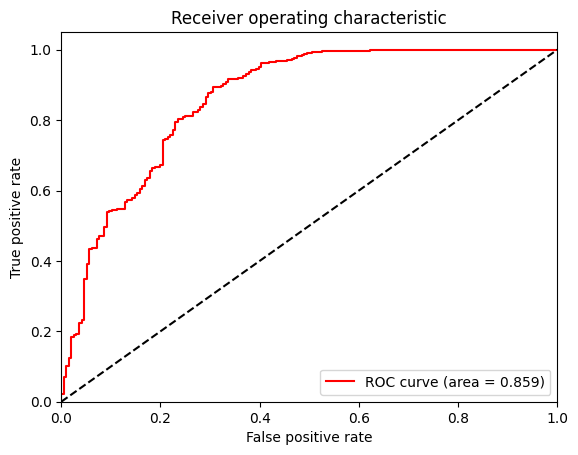

In [107]:
# 偽陽性率と真陽性率の算出
fpr, tpr, thresholds = roc_curve(y_valid, y_valid_pred_proba)

# AUCの算出
auc_value = auc(fpr, tpr)

# ROC曲線の描画
plt.plot(fpr, tpr, color='red', label='ROC curve (area = %.3f)' % auc_value)
plt.plot([0, 1], [0, 1], color='black', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="best")


Top 10 Feature Importances:
                         feature  importance
1                            Age    0.183421
50                School_Encoded    0.025681
28                 Sprint_40yd^2    0.024463
7                    Sprint_40yd    0.022901
14                 Height Weight    0.022271
23          Weight Vertical_Jump    0.020967
25             Weight Broad_Jump    0.020551
17       Height Bench_Press_Reps    0.019662
30  Sprint_40yd Bench_Press_Reps    0.019374
33           Sprint_40yd Shuttle    0.019212


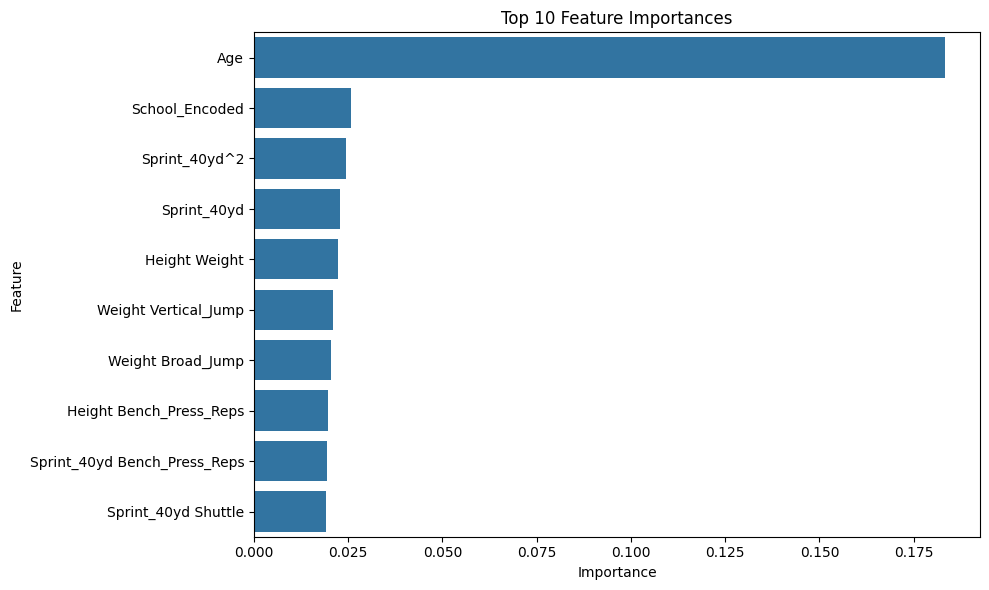

In [108]:
# prompt: 特徴量重要度を知りたい。Top10だけでいいよ

import pandas as pd
import matplotlib.pyplot as plt
# 特徴量の重要度を取得
feature_importances = optimized_model.feature_importances_

# 特徴量名を取得
feature_names = X.columns

# 重要度と特徴量名を組み合わせたデータフレームを作成
importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})

# 重要度で降順にソート
importance_df = importance_df.sort_values('importance', ascending=False)

# Top 10 の特徴量重要度を表示
print("\nTop 10 Feature Importances:")
print(importance_df.head(10))

# Top 10 特徴量重要度の棒グラフを描画
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df.head(10))
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 7. 提出ファイル作成

In [109]:
submission = pd.read_csv(PATH + 'sample_submission.csv')
submission["Drafted"] = test_pred_proba_mean
submission.to_csv(PATH + 'submission.csv', index=False)

files.download(PATH + 'submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. 今後の展望

　本ノートブックでは、データの前処理から特徴量エンジニアリング、モデル構築、評価まで、ベースラインモデルの構築を行いました。

　今後はこのベースラインを土台として、さらに高度な特徴量の工夫やアルゴリズムの改善などによって精度向上を目指していくことができます。例えば、以下のような工夫が考えられます。

- カテゴリデータのエンコーディング手法の変更
- 欠損値の補完手法の変更
- 別のモデルの検討
- モデルのハイパーパラメータ調整
- 特徴量エンジニアリング


　高スコア獲得を目指して、頑張りましょう！